In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler

I0000 00:00:1790689598.290184     130 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790689602.235856     130 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
data = pd.read_csv("moldset_labeled_cn7.csv")

In [4]:
data

,Unnamed: 0,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,0,0,1.679123,1.491397,-0.478017,0.361047,0.978580,-0.711164,1.532018,0,...,-0.533773,0.729073,-1.598068,-0.672350,-1.536620,0.008133,-1.352970,-1.780463,1.023094,1.287574
1,1,0,2.080358,1.894372,-0.527100,1.886261,0.978580,-0.711164,1.471608,0,...,-0.533773,0.056153,0.622557,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339
2,2,0,2.080358,1.894372,-0.527100,1.886261,0.978580,-0.711164,1.471608,0,...,-0.533773,0.056153,0.622557,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339
3,3,0,1.679123,1.894372,-0.527100,1.377857,0.978580,1.202502,1.471608,0,...,-0.533773,0.729073,-0.765355,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339
4,4,0,1.679123,1.894372,-0.527100,1.377857,0.978580,1.202502,1.471608,0,...,-0.533773,0.729073,-0.765355,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1206,1206,0,-1.931915,-1.732320,5.608208,-1.164166,-0.902466,-0.711164,-1.185844,0,...,-0.914898,0.280414,0.067358,1.548728,1.014257,0.623605,0.923887,0.737456,0.093154,-0.155625
1207,1207,0,-4.740484,-4.553063,9.829303,-1.672571,-0.902466,3.116169,-1.487849,0,...,-3.201688,-0.841164,1.177755,-0.989563,1.779489,0.315892,0.013158,1.442471,0.093154,-0.205391
1208,1208,0,-4.740484,-4.553063,9.829303,-1.672571,-0.902466,3.116169,-1.487849,0,...,-3.201688,-0.841164,1.177755,-0.989563,1.779489,0.315892,0.013158,1.442471,0.093154,-0.205391
1209,1209,0,-7.549091,-7.776799,20.038456,-3.706092,-0.902466,6.943503,-2.876962,0,...,-6.631852,0.056153,-0.765355,0.914107,1.651976,-0.299626,2.290016,1.442471,0.093154,-0.205391


## Preprocessing

### 사용하지 않는 열 제거 및 변수들 간 상관관계 분석

In [5]:
data = data.drop("Unnamed: 0", axis =1)

In [6]:
data.head()

,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,0,1.679123,1.491397,-0.478017,0.361047,0.97858,-0.711164,1.532018,0,-1.152398,...,-0.533773,0.729073,-1.598068,-0.672350,-1.536620,0.008133,-1.352970,-1.780463,1.023094,1.287574
1,0,2.080358,1.894372,-0.527100,1.886261,0.97858,-0.711164,1.471608,0,-1.347095,...,-0.533773,0.056153,0.622557,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339
2,0,2.080358,1.894372,-0.527100,1.886261,0.97858,-0.711164,1.471608,0,-1.347095,...,-0.533773,0.056153,0.622557,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339
3,0,1.679123,1.894372,-0.527100,1.377857,0.97858,1.202502,1.471608,0,-1.347095,...,-0.533773,0.729073,-0.765355,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339
4,0,1.679123,1.894372,-0.527100,1.377857,0.97858,1.202502,1.471608,0,-1.347095,...,-0.533773,0.729073,-0.765355,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339


In [7]:
data.describe()

,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
count,1211.000000,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1211.0,1.211000e+03,...,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03
mean,0.014038,-6.440965e-11,1.395541e-10,-4.046242e-11,-4.715112e-10,3.319570e-10,1.824937e-10,-2.551611e-10,0.0,-8.175067e-11,...,6.110649e-11,7.431878e-12,2.477291e-11,2.477305e-12,2.559868e-11,2.477293e-11,6.275804e-11,3.881096e-11,6.606118e-11,2.725032e-11
std,0.117696,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,0.0,1.000413e+00,...,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00
min,0.000000,-7.549091e+00,-7.776799e+00,-7.234252e-01,-3.706092e+00,-9.024657e-01,-2.613163e+00,-2.876962e+00,0.0,-1.541785e+00,...,-6.631852e+00,-2.635662e+00,-2.985979e+00,-2.893331e+00,-2.046826e+00,-4.607976e+00,-2.719099e+00,-2.082616e+00,-1.909796e+00,-1.648589e+00
25%,0.000000,-7.282486e-01,-5.234162e-01,-3.798495e-01,-6.557617e-01,-9.024657e-01,-7.111644e-01,-7.026540e-01,0.0,-5.683212e-01,...,-5.337734e-01,-6.168347e-01,-7.653547e-01,-3.550389e-01,-8.989006e-01,-6.073388e-01,-8.975711e-01,-8.740180e-01,-7.652542e-01,-7.528108e-01
50%,0.000000,-3.270136e-01,-1.204612e-01,-3.627368e-02,3.610475e-01,-9.024657e-01,-7.111644e-01,-6.422898e-01,0.0,1.575557e-02,...,2.284901e-01,5.615323e-02,6.735821e-02,-3.772821e-02,-6.117000e-03,8.132912e-03,1.315810e-02,-1.689960e-01,9.315350e-02,-1.556248e-01
75%,0.000000,8.766531e-01,6.854681e-01,2.091349e-01,3.610475e-01,9.785804e-01,1.202502e+00,1.471608e+00,0.0,4.051425e-01,...,6.096146e-01,7.290727e-01,6.225566e-01,5.968932e-01,8.867055e-01,6.236047e-01,4.685574e-01,7.374564e-01,1.094628e+00,1.287574e+00
max,1.000000,2.080358e+00,2.297327e+00,2.003846e+01,1.256247e+01,2.859537e+00,6.943503e+00,1.592429e+00,0.0,9.555703e+00,...,1.753017e+00,3.196558e+00,3.398379e+00,3.135185e+00,2.544760e+00,3.393298e+00,2.745415e+00,2.550354e+00,1.380764e+00,1.436870e+00


In [8]:
data.isnull().sum()

PassOrFail                  0
Injection_Time              0
Filling_Time                0
Plasticizing_Time           0
Cycle_Time                  0
Clamp_Close_Time            0
Cushion_Position            0
Plasticizing_Position       0
Clamp_Open_Position         0
Max_Injection_Speed         0
Max_Screw_RPM               0
Average_Screw_RPM           0
Max_Injection_Pressure      0
Max_Switch_Over_Pressure    0
Max_Back_Pressure           0
Average_Back_Pressure       0
Barrel_Temperature_1        0
Barrel_Temperature_2        0
Barrel_Temperature_3        0
Barrel_Temperature_4        0
Barrel_Temperature_5        0
Barrel_Temperature_6        0
Hopper_Temperature          0
Mold_Temperature_3          0
Mold_Temperature_4          0
dtype: int64

<Axes: >

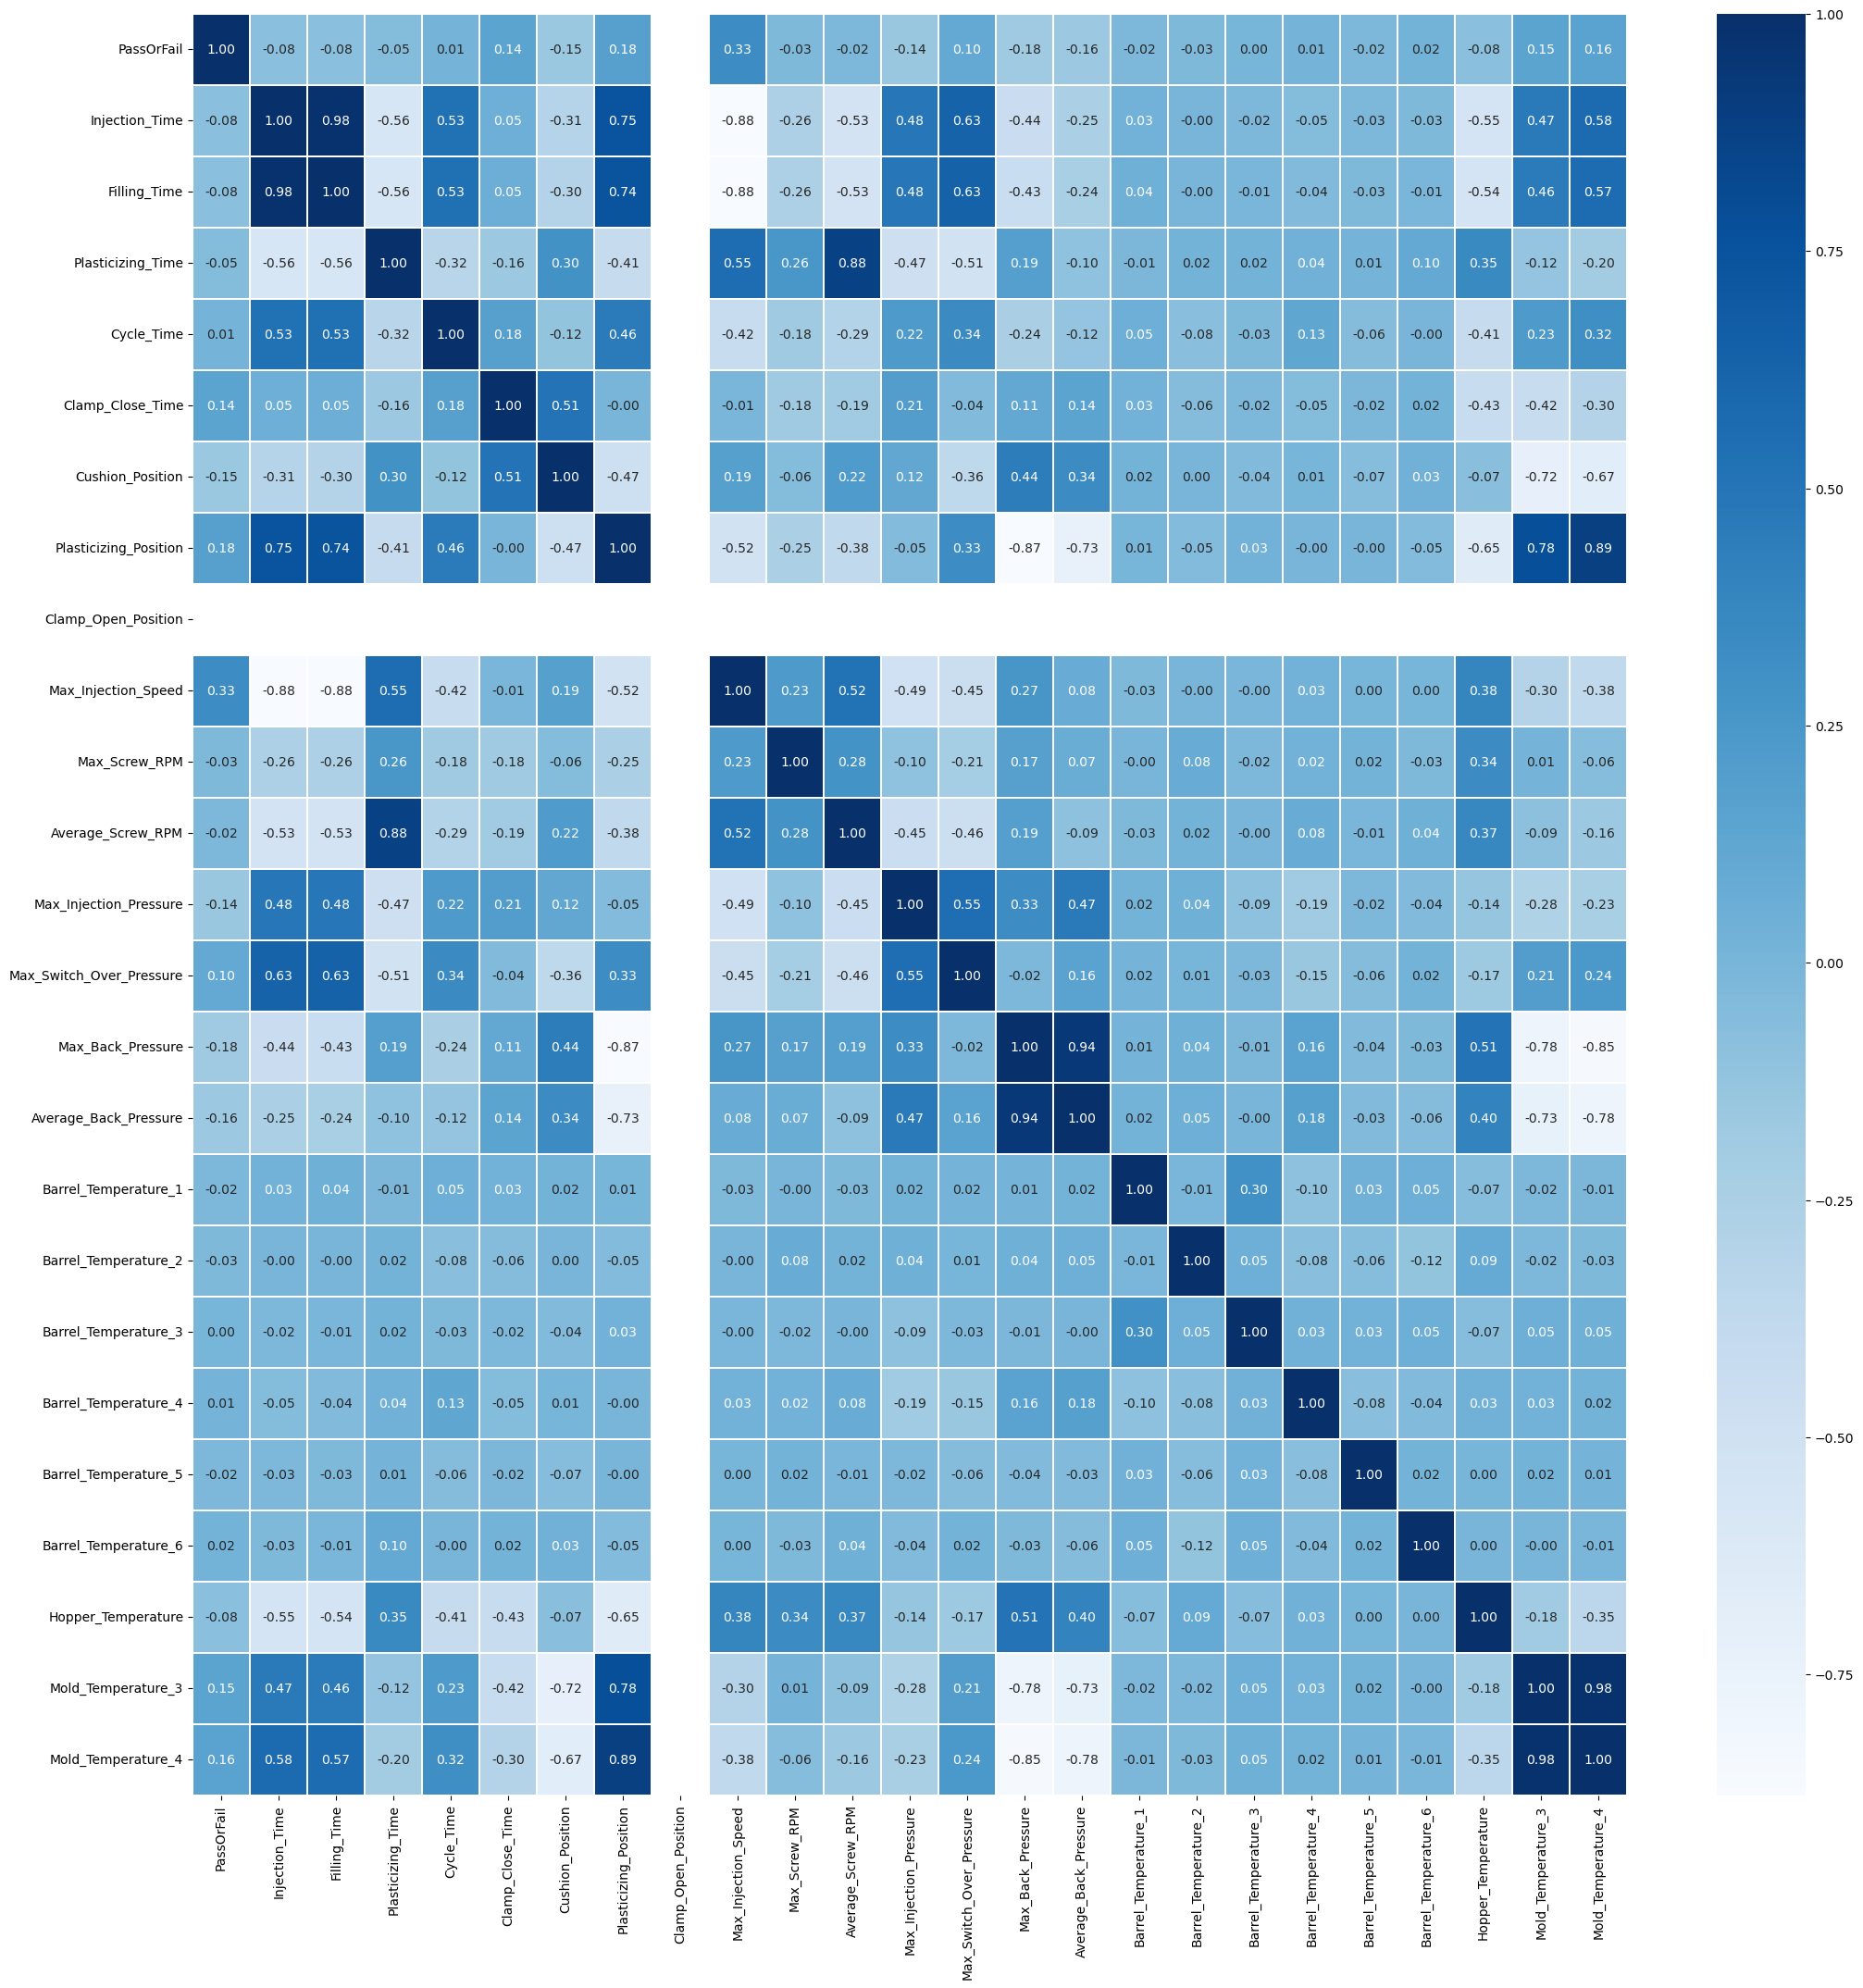

In [9]:

plt.subplots(figsize=(25,25))
sns.heatmap(data = data.corr(), linewidths=0.1, annot=True, fmt='.2f', cmap='Blues')

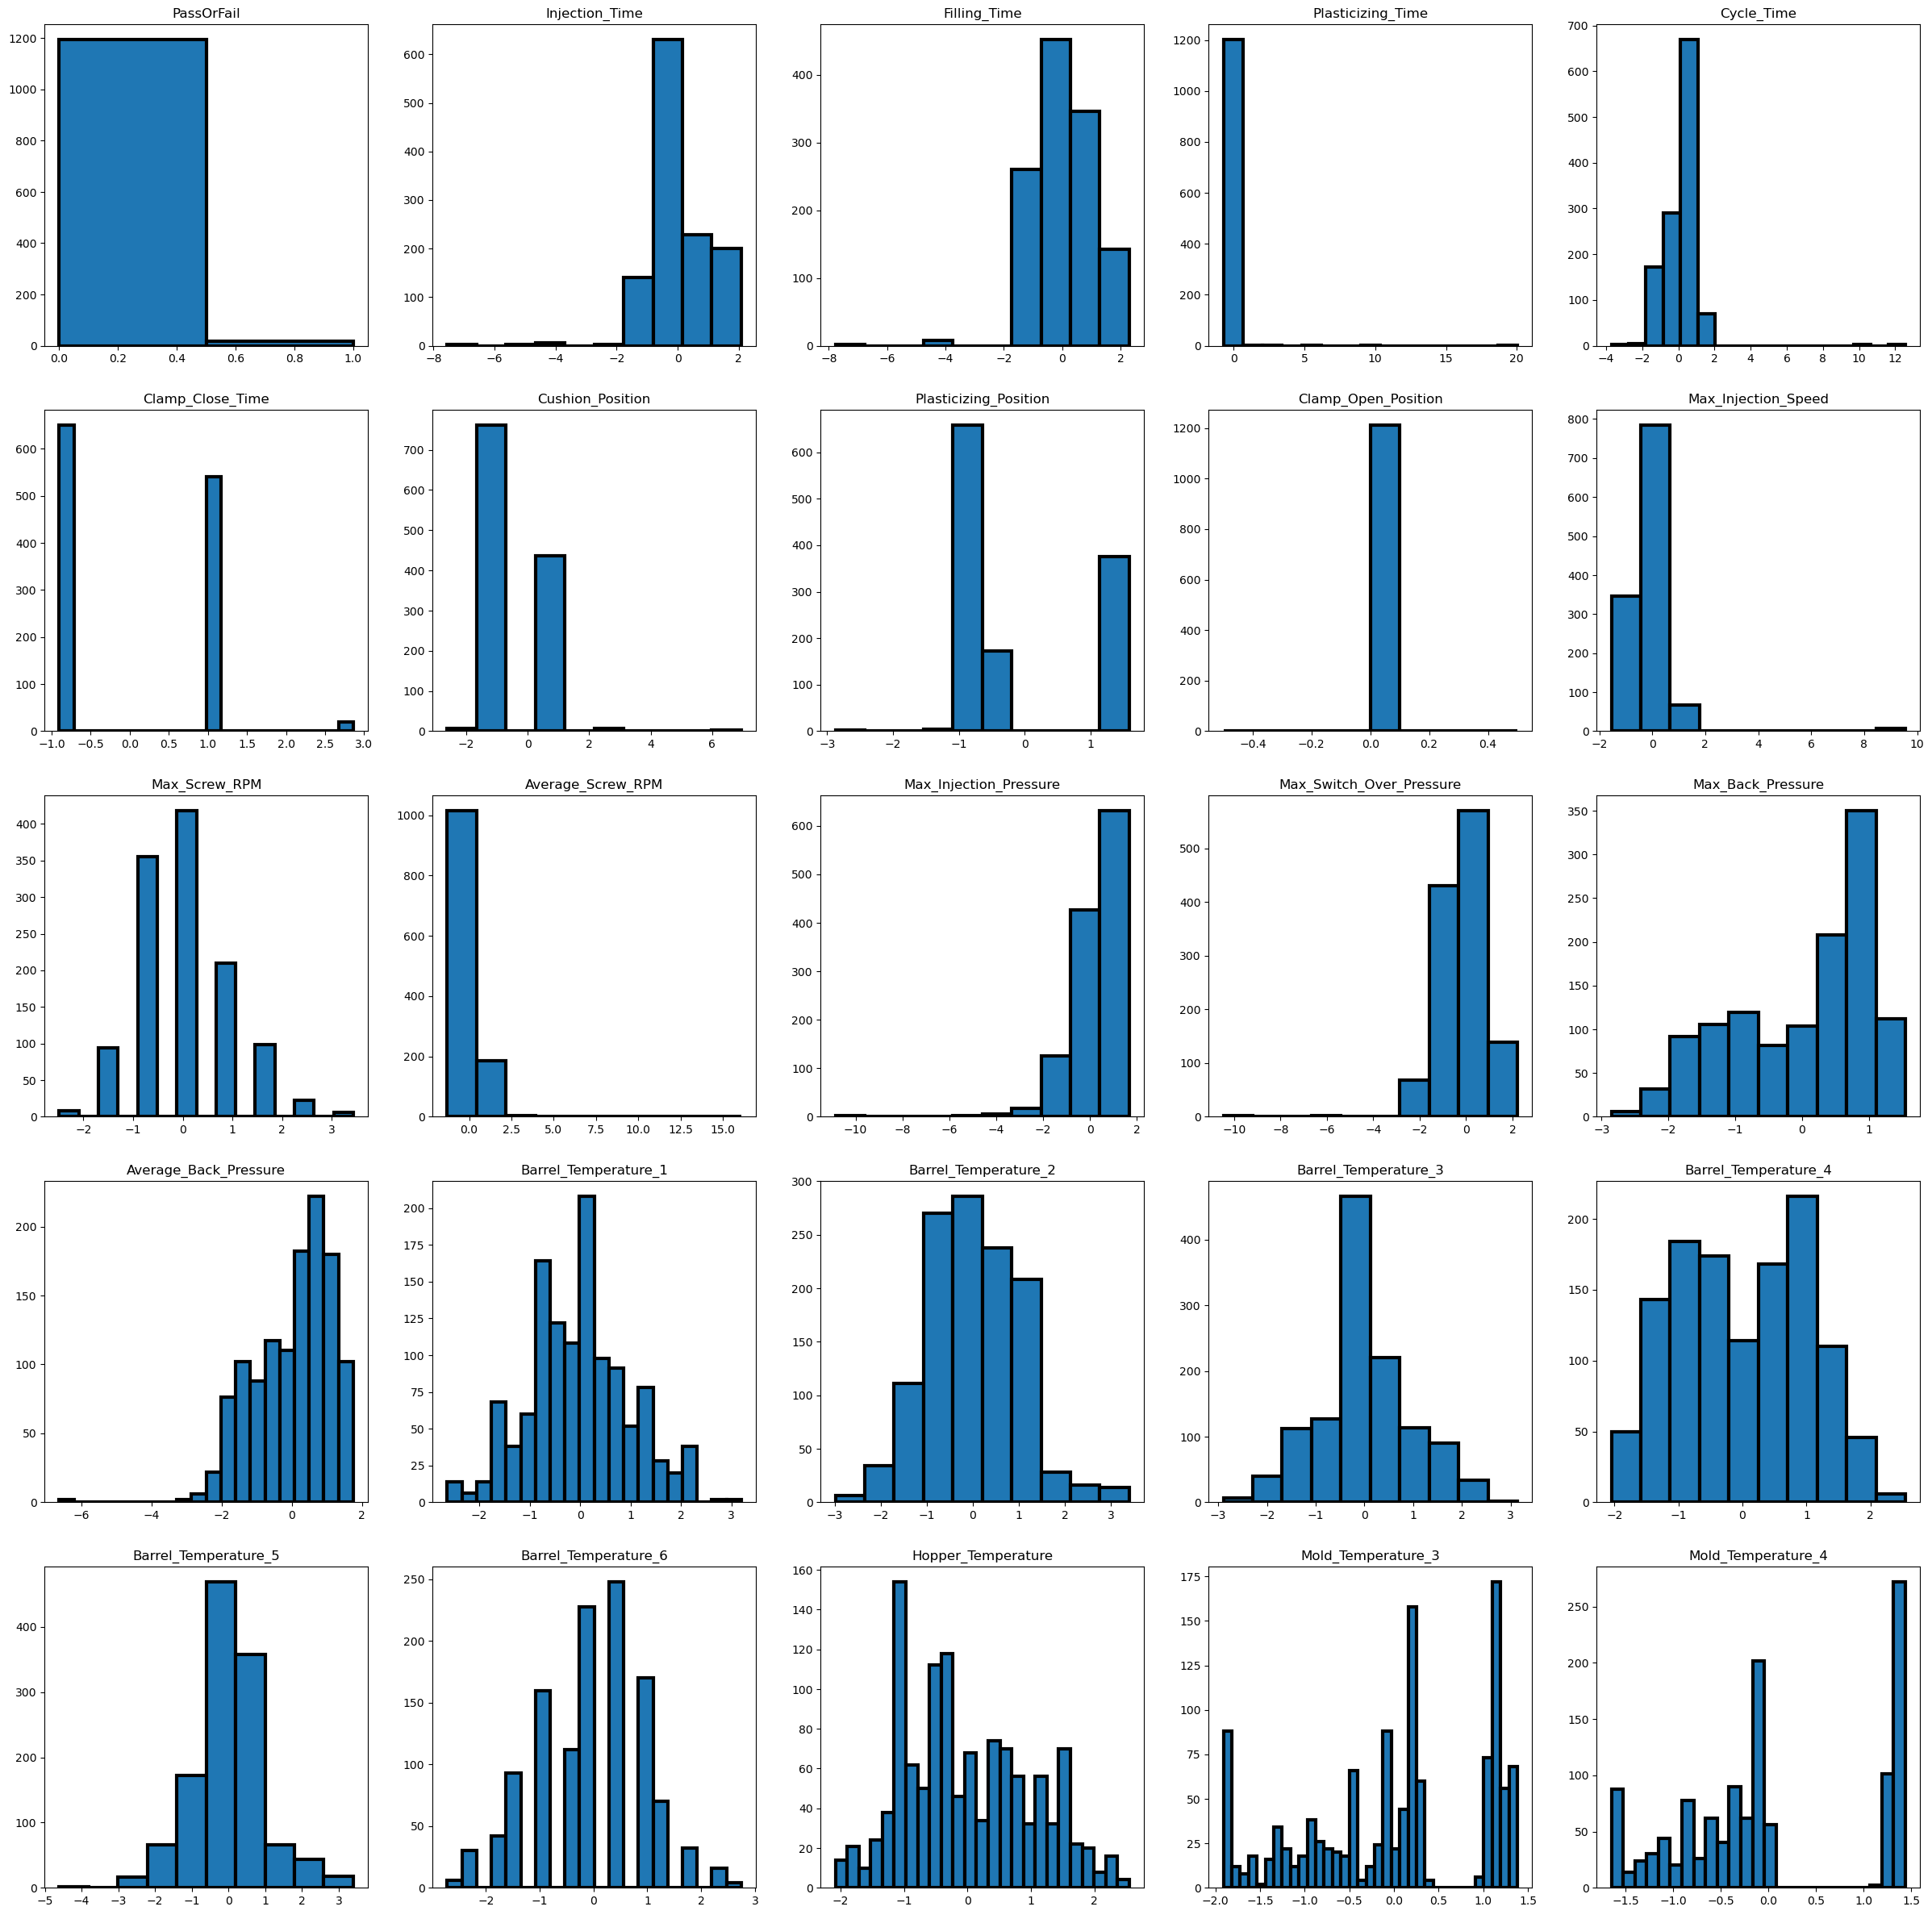

In [10]:
plt.figure(figsize = (30,30))

bin = [2,10,10,15,17,20,
       10,10,10,10,15,10,
       10,10,10,20,20,10,
       10,10,10,20,25,35,25]

for ind, val in enumerate(data):
    sub = plt.subplot(5, 5, ind + 1)
    sub.hist(data[val], bins = bin[ind], linewidth =3,
    edgecolor = 'black')

    plt.title(val)

In [11]:
data['PassOrFail'].value_counts()

PassOrFail
0    1194
1      17
Name: count, dtype: int64

In [12]:
cn7_P = data[data['PassOrFail'] == 0]
print("CN7의 양품 갯수", len(cn7_P))

CN7의 양품 갯수 1194


In [13]:
cn7_N = data[data['PassOrFail'] == 1]
print("CN7의 양품 갯수", len(cn7_P))

CN7의 양품 갯수 1194


In [14]:
cn7_P.head()

,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,0,1.679123,1.491397,-0.478017,0.361047,0.97858,-0.711164,1.532018,0,-1.152398,...,-0.533773,0.729073,-1.598068,-0.672350,-1.536620,0.008133,-1.352970,-1.780463,1.023094,1.287574
1,0,2.080358,1.894372,-0.527100,1.886261,0.97858,-0.711164,1.471608,0,-1.347095,...,-0.533773,0.056153,0.622557,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339
2,0,2.080358,1.894372,-0.527100,1.886261,0.97858,-0.711164,1.471608,0,-1.347095,...,-0.533773,0.056153,0.622557,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339
3,0,1.679123,1.894372,-0.527100,1.377857,0.97858,1.202502,1.471608,0,-1.347095,...,-0.533773,0.729073,-0.765355,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339
4,0,1.679123,1.894372,-0.527100,1.377857,0.97858,1.202502,1.471608,0,-1.347095,...,-0.533773,0.729073,-0.765355,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339


In [15]:
#양품
cn7_P.drop(['PassOrFail'], axis=1, inplace = True)

#불량
cn7_N.drop(['PassOrFail'], axis=1, inplace = True)


/tmp/ipykernel_723/3863633019.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cn7_P.drop(['PassOrFail'], axis=1, inplace = True)
/tmp/ipykernel_723/3863633019.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cn7_N.drop(['PassOrFail'], axis=1, inplace = True)


In [16]:
scaler = MinMaxScaler()

# 양품
cn7_P = scaler.fit_transform(cn7_P)

# 불량
cn7_N = scaler.fit_transform(cn7_N)

In [27]:

standard = int(len(cn7_P) * 0.6)

# 학습 데이터(양품)
cn7_P_train = cn7_P[:standard]

# 테스트 데이터(양품)
cn7_P_test = cn7_P[standard:]

# 테스트 데이터(불량)
cn7_N_test = cn7_N

print("CN7의 양품 학습 데이터셋 개수:", len(cn7_P_train))
print("CN7의 양품 테스트 데이터셋 개수:", len(cn7_P_test))
print("CN7의 불량 테스트 데이터셋 개수:", len(cn7_N_test))


CN7의 양품 학습 데이터셋 개수: 716
CN7의 양품 테스트 데이터셋 개수: 478
CN7의 불량 테스트 데이터셋 개수: 17


In [28]:
# 인코더
dropout_encoder = Sequential([
    Dropout(0.3),
    Dense(15, activation="relu"),  # 첫 번째 은닉층
    Dense(5, activation="relu")    # 두 번째 은닉층
])

# 디코더
dropout_decoder = Sequential([
    Dense(15, activation="relu", input_shape=(5,)),  # 세 번째 은닉층
    Dense(cn7_P_train.shape[1], activation="relu")   # 출력층
])

# 오토인코더
dropout_AE = Sequential([dropout_encoder,dropout_decoder])

In [49]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# 손실함수와 옵티마이저 설정
dropout_AE.compile(
    loss="mse",
    optimizer=Adam(learning_rate=0.05),
    metrics=["accuracy"]
)

# 모델 학습
history = dropout_AE.fit(
    cn7_P_train,
    cn7_P_train,
    batch_size=30,
    epochs=30,
    validation_split=0.2,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=7,
            mode="min"
        )
    ]
)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4983 - loss: 0.0164 - val_accuracy: 0.6528 - val_loss: 0.0163
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5262 - loss: 0.0186 - val_accuracy: 0.6111 - val_loss: 0.0196
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5017 - loss: 0.0200 - val_accuracy: 0.6111 - val_loss: 0.0193
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4720 - loss: 0.0193 - val_accuracy: 0.6528 - val_loss: 0.0162
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5350 - loss: 0.0190 - val_accuracy: 0.6528 - val_loss: 0.0140
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5524 - loss: 0.0178 - val_accuracy: 0.6528 - val_loss: 0.0145
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5507 - loss: 0.0177 - val_accuracy: 0.5972 - val_loss: 0.0202
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4755 - loss: 0.0203 - val_accuracy: 0.5972 - val_loss

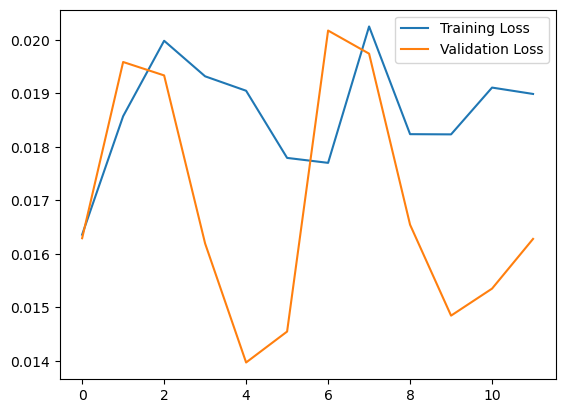

In [50]:
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label= 'Validation Loss')

plt.legend()
plt.show()

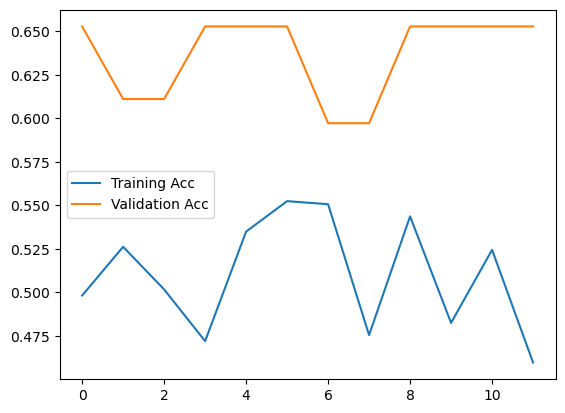

In [51]:
plt.plot(history.history["accuracy"], label="Training Acc")
plt.plot(history.history["val_accuracy"], label="Validation Acc")
plt.legend()
plt.show()

In [52]:
import numpy as np

# 학습 데이터의 예측값
cn7_train_pred = dropout_AE.predict(cn7_P_train)

# 학습 데이터의 복원 오차 (예측값 - 실제 값)
cn7_train_loss = np.mean(
    np.square(cn7_train_pred - cn7_P_train),
    axis=1
)

# 임계치
threshold = np.mean(cn7_train_loss) + 5 * np.std(cn7_train_loss)

print("복원 오류 임계치:", threshold)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
복원 오류 임계치: 0.047359280086753816


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


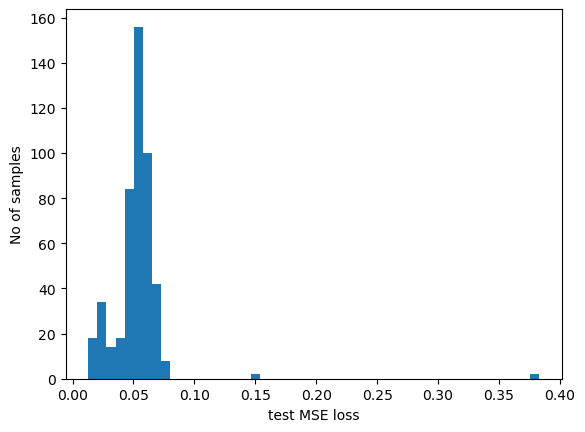

불량 개수:  362


In [54]:
# 평가 데이터의 양품

# 예측값
cn7_predict_Y = dropout_AE.predict(cn7_P_test)

# 양품 평가 데이터의 복원 오차 (예측값 - 실제 값)
cn7_test_Y_mse= np.mean(np.square(cn7_predict_Y - cn7_P_test), axis=1)

# 시각화
plt.hist(cn7_test_Y_mse, bins=50)
plt.xlabel("test MSE loss")
plt.ylabel("No of samples")
plt.show()

# 불량으로 판단한 데이터 확인
cv7_test_Y_anomalies = cn7_test_Y_mse > threshold
print("불량 개수: ", np.sum(cv7_test_Y_anomalies)) #결과는 아래에서 확인 가능하다.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


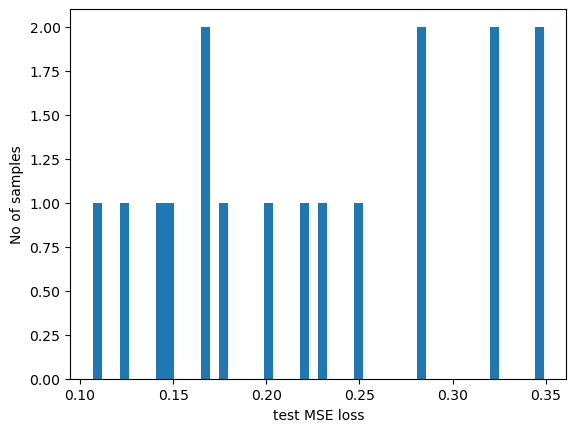

불량 개수:  17


In [56]:
# 평가 데이터의 불량

# 예측값
cn7_predict_N = dropout_AE.predict(cn7_N_test)

# 불량 평가 데이터의 복원 오차 (예측값 - 실제 값)
cn7_test_N_mse = np.mean(np.square(cn7_predict_N - cn7_N_test), axis=1)

# 시각화
plt.hist(cn7_test_N_mse, bins=50)
plt.xlabel("test MSE loss")
plt.ylabel("No of samples")
plt.show()

# 불량으로 판단한 데이터 확인
cv7_test_N_anomalies = cn7_test_N_mse > threshold
print("불량 개수: ", np.sum(cv7_test_N_anomalies)) #결과는 아래에서 확인 가능하다.

In [57]:
cn7_true = np.concatenate([np.zeros(len(cv7_test_Y_anomalies)), np.ones(len(cv7_test_N_anomalies))])

In [58]:
cn7_prediction = np.concatenate([cv7_test_Y_anomalies, cv7_test_N_anomalies])

In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("정확도:", accuracy_score(cn7_true, cn7_prediction))
print("정밀도:", precision_score(cn7_true, cn7_prediction))
print("재현율:", recall_score(cn7_true, cn7_prediction))
print("F1:", f1_score(cn7_true, cn7_prediction)) #결과는 아래에서 확인 가능하다.

정확도: 0.2686868686868687
정밀도: 0.044854881266490766
재현율: 1.0
F1: 0.08585858585858586
